In [64]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
#dataset = load_dataset('lukebarousse/data_jobs')
#df = dataset['train'].to_pandas()

df = pd.read_csv("D:\Python_Data_Project\Project\job_postings_up_to_date.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

#df = df[df['job_posted_date'].dt.year == 2025 ]

MemoryError: Unable to allocate 62.7 MiB for an array with shape (8224407, 1) and data type float64

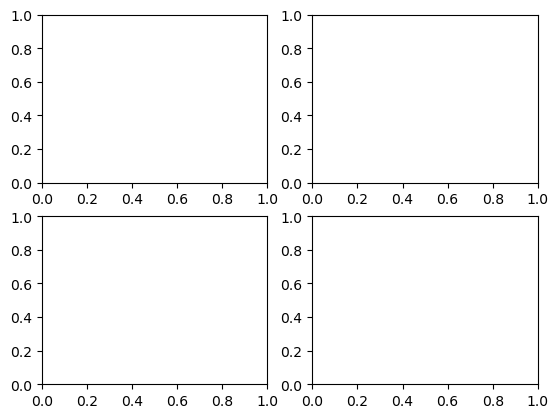

In [69]:
fig, ax = plt.subplots(2,2)
job_list = ['Data Analyst', 'Data Scientist', 'Machine Learning Engineer']
df['job_posted_year'] = df['job_posted_date'].dt.year
df['job_posted_month'] = df['job_posted_date'].dt.month

#change after to create a list of these filtered years to clean up code
#filtering for desired job titles, locations and years
df_filtered_2023 = df[(df['job_title_short'].isin(job_list))&
            (df['job_country'] == 'United Kingdom')&
            (df['job_posted_year'] == 2023)]


# df_filtered_2024 = df[(df['job_title_short'].isin(job_list))&
#             (df['job_country'] == 'United Kingdom')&
#             (df['job_posted_year'] == 2024)]


# df_filtered_2025 = df[(df['job_title_short'].isin(job_list))&
#             (df['job_country'] == 'United Kingdom')&
#             (df['job_posted_year'] == 2025)]

df_explode = df.explode('job_skills').dropna(subset = 'job_skills')

#setting up dataframes for each year
df_2023 = df_explode[df_explode['job_posted_year'] == 2023]
# df_2024 = df_explode[df_explode['job_posted_year'] == 2024]
# df_2025 = df_explode[df_explode['job_posted_year'] == 2025]
# df_years = [df_2023, df_2024, df_2025]

#creating plot for 2023
pivot_skill_counts = df_2023.pivot_table(index = 'job_posted_month',
                                           columns = 'job_skills',
                                             aggfunc = 'size',
                                             fill_value = 0)
pivot_skill_counts.loc['total'] = pivot_skill_counts.sum()
pivot_skill_counts = pivot_skill_counts[pivot_skill_counts.loc['total'].sort_values(ascending = False).index]
pivot_skill_counts = pivot_skill_counts.iloc[:, :5]
pivot_totals = df_filtered_2023.groupby(by = 'job_posted_month').size()
pivot_skill_perc = (pivot_skill_counts.iloc[:12].div(pivot_totals/100, axis=0))

pivot_totals



#creating the 3 different figures for 2023, 2024, 2025
# for i, year in enumerate(df_years):
#     pivot_skill_counts = year.pivot_table(index = 'job_posted_month',
#                                            columns = 'job_skills',
#                                              aggfunc = 'size',
#                                              fill_value = 0)
#     pivot_skill_counts.loc['total'] = pivot_skill_counts.sum()
#     pivot_skill_counts = pivot_skill_counts[pivot_skill_counts.loc['total'].sort_values(ascending = False).index]
#     #pivot_skill_counts = pivot_skill_counts.iloc[:, :5]
#     pivot_totals = year.groupby(by = 'job_posted_month').size()
#     pivot_skill_perc = (pivot_skill_counts.iloc[:12].div(pivot_totals/100, axis=0))
#     #print(pivot_skill_counts)
#     #print(pivot_totals)
#     print(pivot_skill_perc)

    


    




In [53]:
df_filtered

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_year,job_posted_month
272,Data Analyst,Data Analyst or Data Scientist,"Leeds, UK",via My ArkLaMiss Jobs,Full-time,False,United Kingdom,2023-01-01 00:29:50,False,False,United Kingdom,NaN,NaN,NaN,Elevation Recruitment Group,NaN,NaN,2023,1
274,Data Analyst,Junior Data Analyst Apprentice,"Blackburn, UK",via Big Country Jobs,Full-time,False,United Kingdom,2023-01-01 00:29:50,True,False,United Kingdom,NaN,NaN,NaN,Baltic Training Services,NaN,NaN,2023,1
275,Data Analyst,Data Analyst,"Market Harborough, UK",via Big Country Jobs,Full-time,False,United Kingdom,2023-01-01 00:29:50,True,False,United Kingdom,NaN,NaN,NaN,G Touring,NaN,NaN,2023,1
276,Data Analyst,Data Analyst,United Kingdom,via CW39 Jobs,Full-time,False,United Kingdom,2023-01-01 00:29:52,True,False,United Kingdom,NaN,NaN,NaN,Page Personnel Finance,"[sql, mysql, azure, power bi]","{'analyst_tools': ['power bi'], 'cloud': ['azu...",2023,1
277,Data Analyst,Racing Data Analyst,"Hull, UK",via My ArkLaMiss Jobs,Full-time,False,United Kingdom,2023-01-01 00:29:52,True,False,United Kingdom,NaN,NaN,NaN,PA Media Group,NaN,NaN,2023,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1779970,Data Scientist,Data Scientist | The Christie NHS Foundation T...,"Radcliffe, United Kingdom",Women For Hire- Job Board,Full-time,False,United Kingdom,2025-12-31 15:11:05,False,False,United Kingdom,NaN,NaN,NaN,Career Choices Dewis Gyrfa Ltd,NaN,NaN,2025,12
1779971,Data Scientist,"Clinical Data Scientist – CODU, Manchester","Stretford, United Kingdom",Women For Hire- Job Board,Full-time,False,United Kingdom,2025-12-31 15:11:05,False,False,United Kingdom,NaN,NaN,NaN,Career Choices Dewis Gyrfa Ltd,"[python, sql]","{'programming': ['python', 'sql']}",2025,12
1779972,Data Scientist,Lead Data Scientist,"Hanwell, United Kingdom",Women For Hire- Job Board,Full-time,False,United Kingdom,2025-12-31 15:11:05,False,False,United Kingdom,NaN,NaN,NaN,Data Science Festival,"[python, sql]","{'programming': ['python', 'sql']}",2025,12
1779988,Machine Learning Engineer,"AI/MLOps Engineer, Platform",United Kingdom,LinkedIn,Full-time,False,United Kingdom,2025-12-31 16:11:05,False,False,United Kingdom,NaN,NaN,NaN,Wiraa,"[python, aws, databricks, azure, hugging face,...","{'cloud': ['aws', 'databricks', 'azure'], 'lib...",2025,12
